In [1]:
import warnings


warnings.filterwarnings("ignore")

# Optional specific suppressions
warnings.filterwarnings(
    "ignore",
    message="CUDA initialization"
)

warnings.filterwarnings(
    "ignore",
    message="IProgress not found"
)

import os
import gc
import json
import torch
import random
import numpy as np
import pandas as pd

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)


print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch Version: 2.6.0+cu124
CUDA Available: True
GPU: NVIDIA RTX A6000


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [3]:
# PATHS FOR HYPERTUNING EXPERIMENTS


import os

BASE_PATH = "/home/jovyan/work"

# DATASETS
COURSE_PATH = f"{BASE_PATH}/course_balanced.csv"

TEACHER_PATH = f"{BASE_PATH}/teacher_balanced.csv"

UNIVERSITY_PATH = f"{BASE_PATH}/university_balanced.csv"

# SHARED TEST SETS
SHARED_TEST_PATH = (
    f"{BASE_PATH}/Dissertation/shared_test_sets"
)

# HYPERTUNING OUTPUTS
HYPERTUNE_BASE = (
    f"{BASE_PATH}/Dissertation/multidomain_llama_hypertuning"
)


LR_1E5_OUTPUT = f"{HYPERTUNE_BASE}/lr_1e5"

LR_5E5_OUTPUT = f"{HYPERTUNE_BASE}/lr_5e5"

EPOCH_5_OUTPUT = f"{HYPERTUNE_BASE}/epoch_5"



os.makedirs(HYPERTUNE_BASE, exist_ok=True)

os.makedirs(LR_1E5_OUTPUT, exist_ok=True)

os.makedirs(LR_5E5_OUTPUT, exist_ok=True)

os.makedirs(EPOCH_5_OUTPUT, exist_ok=True)

print("Hypertuning directories created successfully.")

Hypertuning directories created successfully.


In [4]:
course_df = pd.read_csv(COURSE_PATH)
teacher_df = pd.read_csv(TEACHER_PATH)
university_df = pd.read_csv(UNIVERSITY_PATH)

print("Course Shape:", course_df.shape)
print("Teacher Shape:", teacher_df.shape)
print("University Shape:", university_df.shape)

Course Shape: (4218, 4)
Teacher Shape: (4218, 4)
University Shape: (4218, 4)


In [5]:
course_df["domain"] = "course"
teacher_df["domain"] = "teacher"
university_df["domain"] = "university"

print(course_df.head())

                                              review              aspect  \
0  This course was amazing. For the first time, t...              course   
1  This course was amazing. For the first time, t...         lab partner   
2  Extremely boring and lectures were useless, bu...            lectures   
3  Extremely boring and lectures were useless, bu...  information taught   
4  Cool course content, requires effort to get it...      course content   

  sentiment  domain  
0  positive  course  
1  positive  course  
2  negative  course  
3  positive  course  
4  positive  course  


In [6]:
def add_row_id(df, domain_name):

    df = df.reset_index(drop=True)

    df["row_id"] = [
        f"{domain_name}_{i}" for i in range(len(df))
    ]

    return df

course_df = add_row_id(course_df, "course")
teacher_df = add_row_id(teacher_df, "teacher")
university_df = add_row_id(university_df, "university")

print(course_df[["row_id", "review", "aspect", "sentiment"]].head())

     row_id                                             review  \
0  course_0  This course was amazing. For the first time, t...   
1  course_1  This course was amazing. For the first time, t...   
2  course_2  Extremely boring and lectures were useless, bu...   
3  course_3  Extremely boring and lectures were useless, bu...   
4  course_4  Cool course content, requires effort to get it...   

               aspect sentiment  
0              course  positive  
1         lab partner  positive  
2            lectures  negative  
3  information taught  positive  
4      course content  positive  


In [7]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Convert sentiment labels to integers
course_df["label"] = course_df["sentiment"].map(label2id)
teacher_df["label"] = teacher_df["sentiment"].map(label2id)
university_df["label"] = university_df["sentiment"].map(label2id)

print(course_df[["sentiment", "label"]].head())

  sentiment  label
0  positive      2
1  positive      2
2  negative      0
3  positive      2
4  positive      2


In [8]:
from sklearn.model_selection import train_test_split

def split_domain(df):

    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["label"],
        random_state=SEED
    )

    return train_df, test_df

course_train, course_test = split_domain(course_df)
teacher_train, teacher_test = split_domain(teacher_df)
university_train, university_test = split_domain(university_df)

print("Course Train/Test:", course_train.shape, course_test.shape)
print("Teacher Train/Test:", teacher_train.shape, teacher_test.shape)
print("University Train/Test:", university_train.shape, university_test.shape)

Course Train/Test: (3374, 6) (844, 6)
Teacher Train/Test: (3374, 6) (844, 6)
University Train/Test: (3374, 6) (844, 6)


In [12]:
import os

BASE_PATH = "/home/jovyan/work"

DISSERTATION_PATH = f"{BASE_PATH}/Dissertation"


SHARED_TEST_PATH = (
    f"{DISSERTATION_PATH}/shared_test_sets"
)

PLOTS_PATH = (
    f"{DISSERTATION_PATH}/plots"
)

METRICS_PATH = (
    f"{DISSERTATION_PATH}/metrics"
)


HYPERTUNING_PATH = (
    f"{DISSERTATION_PATH}/multidomain_llama_hypertuning"
)

LR_1E5_PATH = (
    f"{HYPERTUNING_PATH}/lr_1e5"
)

LR_5E5_PATH = (
    f"{HYPERTUNING_PATH}/lr_5e5"
)

EPOCH_5_PATH = (
    f"{HYPERTUNING_PATH}/epoch_5"
)

# MAIN DIRECTORIES

os.makedirs(DISSERTATION_PATH, exist_ok=True)

os.makedirs(SHARED_TEST_PATH, exist_ok=True)

os.makedirs(PLOTS_PATH, exist_ok=True)

os.makedirs(METRICS_PATH, exist_ok=True)

# HYPERTUNING DIRECTORIES

os.makedirs(HYPERTUNING_PATH, exist_ok=True)

os.makedirs(LR_1E5_PATH, exist_ok=True)

os.makedirs(LR_5E5_PATH, exist_ok=True)

os.makedirs(EPOCH_5_PATH, exist_ok=True)



print("Hypertuning directory structure created successfully.\n")

print("Main Dissertation Path:")
print(DISSERTATION_PATH)

print("\nShared Paths:")
print("- shared_test_sets")
print("- plots")
print("- metrics")

print("\nHypertuning Experiment Folders:")
print("- lr_1e5")
print("- lr_5e5")
print("- epoch_5")

Hypertuning directory structure created successfully.

Main Dissertation Path:
/home/jovyan/work/Dissertation

Shared Paths:
- shared_test_sets
- plots
- metrics

Hypertuning Experiment Folders:
- lr_1e5
- lr_5e5
- epoch_5


In [13]:
course_test.to_csv(
    f"{SHARED_TEST_PATH}/course_test_shared.csv",
    index=False
)

teacher_test.to_csv(
    f"{SHARED_TEST_PATH}/teacher_test_shared.csv",
    index=False
)

university_test.to_csv(
    f"{SHARED_TEST_PATH}/university_test_shared.csv",
    index=False
)

print("Shared test sets saved successfully.")

print("\nSaved Files:")
print("- course_test_shared.csv")
print("- teacher_test_shared.csv")
print("- university_test_shared.csv")

Shared test sets saved successfully.

Saved Files:
- course_test_shared.csv
- teacher_test_shared.csv
- university_test_shared.csv


In [14]:
multidomain_train_df = pd.concat(
    [
        course_train,
        teacher_train,
        university_train
    ],
    ignore_index=True
)

print("Multidomain Train Dataset Shape:")
print(multidomain_train_df.shape)

print("\nDomain Distribution:")
print(multidomain_train_df["domain"].value_counts())

Multidomain Train Dataset Shape:
(10122, 6)

Domain Distribution:
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64


In [15]:
datasets_dict = {
    "course": course_df,
    "teacher": teacher_df,
    "university": university_df
}

for name, df in datasets_dict.items():

    print("=" * 60)
    print(f"{name.upper()} DATASET OVERVIEW")
    print("=" * 60)

    # Shape
    print("\nDataset Shape:")
    print(df.shape)

    # Columns
    print("\nColumns:")
    print(df.columns.tolist())

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate rows
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    # Unique aspects
    print("\nUnique Aspects:")
    print(df["aspect"].nunique())

    # Sentiment distribution
    print("\nSentiment Distribution:")
    print(df["sentiment"].value_counts())

    # Average review length
    avg_words = df["review"].apply(
        lambda x: len(str(x).split())
    ).mean()

    print("\nAverage Review Length (words):")
    print(round(avg_words, 2))

    # Display sample rows
    print("\nSample Rows:")
    display(
        df[
            [
                "row_id",
                "review",
                "aspect",
                "sentiment",
                "domain"
            ]
        ].head()
    )

    print("\n\n")

COURSE DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
1485

Sentiment Distribution:
sentiment
positive    2039
negative    1456
neutral      723
Name: count, dtype: int64

Average Review Length (words):
50.17

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,course_0,"This course was amazing. For the first time, t...",course,positive,course
1,course_1,"This course was amazing. For the first time, t...",lab partner,positive,course
2,course_2,"Extremely boring and lectures were useless, bu...",lectures,negative,course
3,course_3,"Extremely boring and lectures were useless, bu...",information taught,positive,course
4,course_4,"Cool course content, requires effort to get it...",course content,positive,course





TEACHER DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
1697

Sentiment Distribution:
sentiment
positive    2345
negative    1437
neutral      436
Name: count, dtype: int64

Average Review Length (words):
64.56

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,teacher_0,"First of all, shoutout to Scott Hopkins for th...",Scott Hopkins,positive,teacher
1,teacher_1,this lady is a very harsh grader and talks ent...,this lady,negative,teacher
2,teacher_2,"If you are going into the health sciences, you...",this class,positive,teacher
3,teacher_3,Terrible teacher! Does not care about anyone o...,teacher,negative,teacher
4,teacher_4,his a good teacher but extermely difficult... ...,teacher,positive,teacher





UNIVERSITY DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
503

Sentiment Distribution:
sentiment
positive    3380
negative     657
neutral      181
Name: count, dtype: int64

Average Review Length (words):
47.73

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,university_0,"I was excited to take this class. However, the...",program,negative,university
1,university_1,"Exeter has been great so far, everyone friendl...",everyone,positive,university
2,university_2,Fantastic university- love my course and the f...,course,positive,university
3,university_3,"Exeter is a very good school, the teachers are...",teachers,positive,university
4,university_4,Sports facilities are improving enormously!,Sports facilities,positive,university


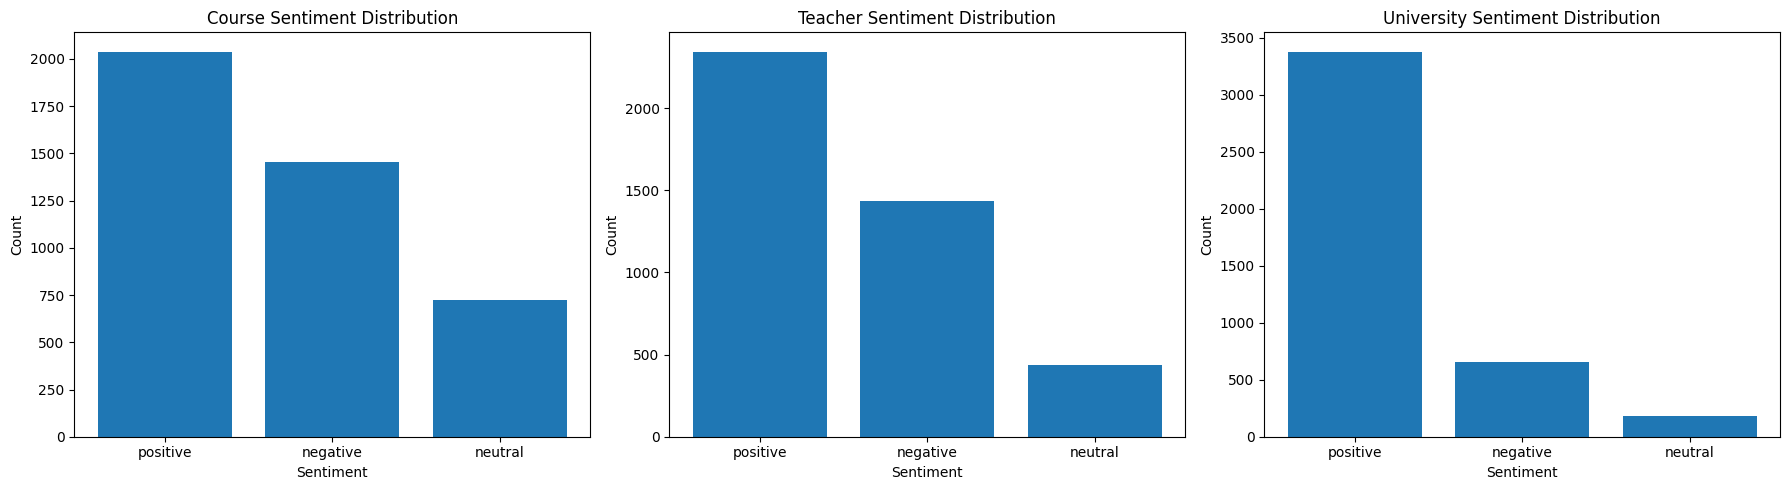

Sentiment distribution plot saved.


In [16]:
# SENTIMENT DISTRIBUTION VISUALIZATION


import matplotlib.pyplot as plt

domains = ["course", "teacher", "university"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, df) in enumerate(datasets_dict.items()):

    sentiment_counts = df["sentiment"].value_counts()

    axes[i].bar(
        sentiment_counts.index,
        sentiment_counts.values
    )

    axes[i].set_title(f"{name.capitalize()} Sentiment Distribution")

    axes[i].set_xlabel("Sentiment")
    axes[i].set_ylabel("Count")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/sentiment_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Sentiment distribution plot saved.")

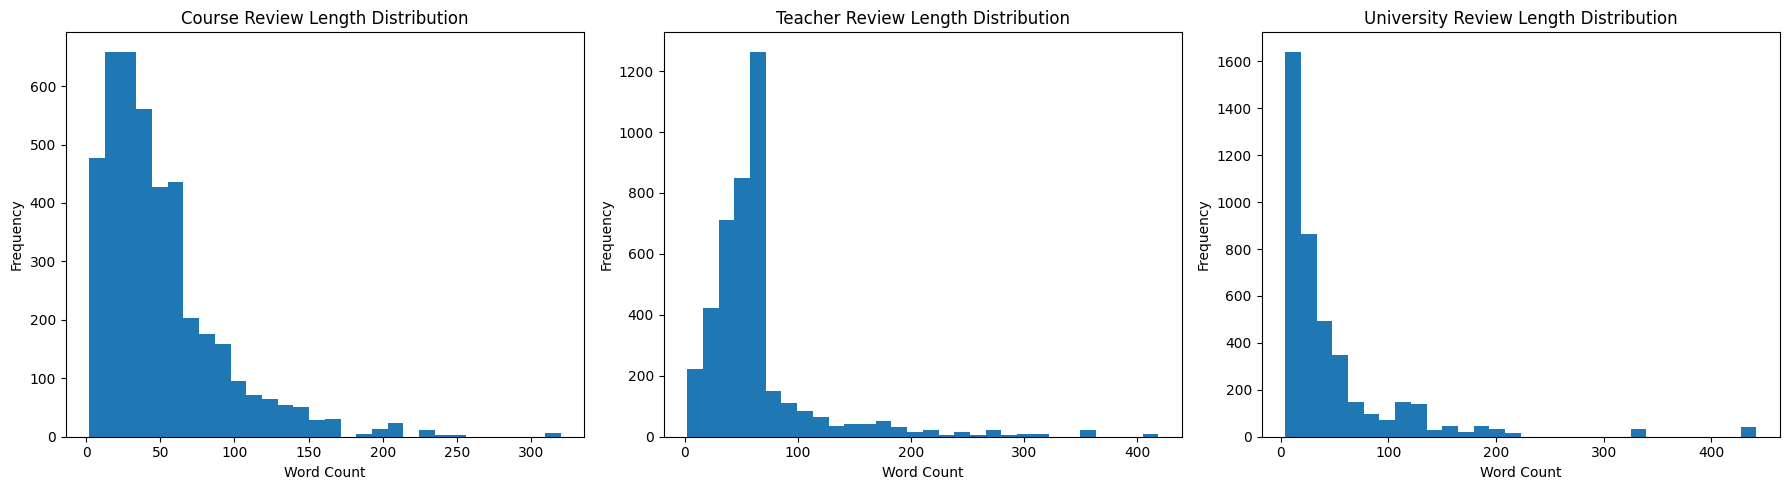

Review length distribution plot saved successfully.


In [17]:
# REVIEW LENGTH DISTRIBUTION


# Create review length column
for df in datasets_dict.values():

    df["review_length"] = df["review"].apply(
        lambda x: len(str(x).split())
    )

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, df) in enumerate(datasets_dict.items()):

    axes[i].hist(
        df["review_length"],
        bins=30
    )

    axes[i].set_title(
        f"{name.capitalize()} Review Length Distribution"
    )

    axes[i].set_xlabel("Word Count")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/review_length_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Review length distribution plot saved successfully.")

TOP 15 ASPECTS - COURSE
aspect
course         871
this course    221
class          145
assignments    142
content        138
material        68
lectures        60
midterm         52
concepts        52
final           46
textbook        44
this class      42
labs            38
exams           37
topics          37
Name: count, dtype: int64


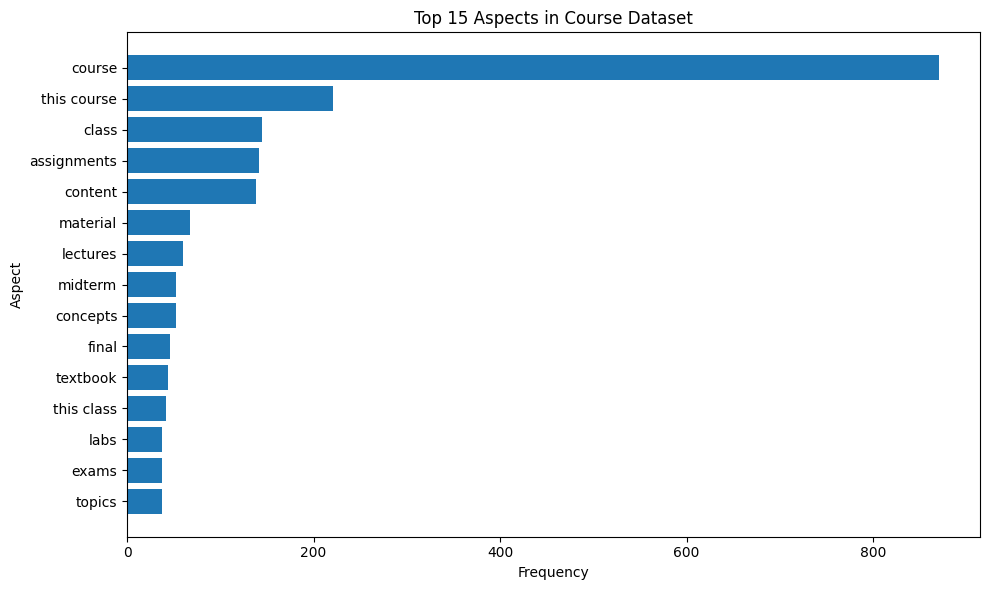

TOP 15 ASPECTS - TEACHER
aspect
class          271
professor      257
teacher        245
course         225
this class     120
prof            81
this course     79
tests           59
assignments     55
lectures        55
content         47
material        44
textbook        37
homework        37
work            31
Name: count, dtype: int64


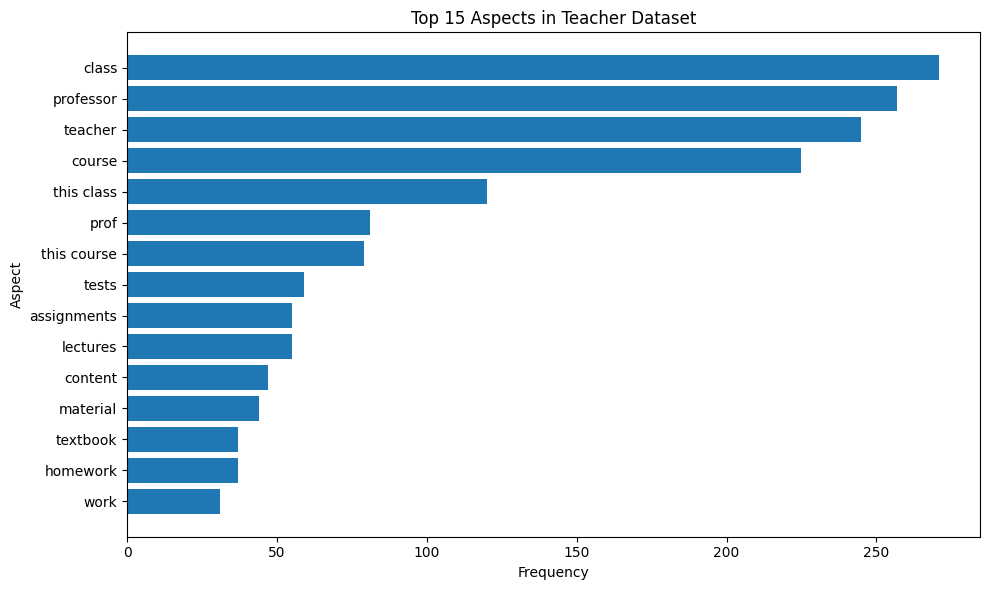

TOP 15 ASPECTS - UNIVERSITY
aspect
campus                  403
university              337
facilities              218
uni                     153
societies               127
staff                    95
lecturers                83
people                   54
course                   51
city                     45
University of Exeter     43
teachers                 42
opportunities            41
teaching                 39
environment              37
Name: count, dtype: int64


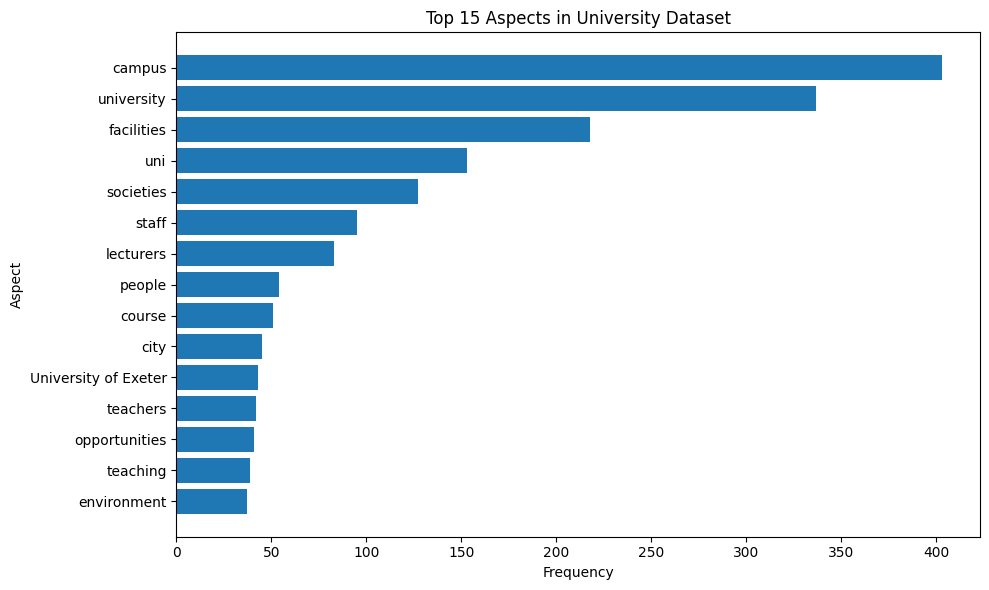

In [18]:
TOP_N = 15

for name, df in datasets_dict.items():

    print("=" * 60)
    print(f"TOP {TOP_N} ASPECTS - {name.upper()}")
    print("=" * 60)

    top_aspects = df["aspect"].value_counts().head(TOP_N)

    print(top_aspects)

    
    plt.figure(figsize=(10, 6))

    plt.barh(
        top_aspects.index[::-1],
        top_aspects.values[::-1]
    )

    plt.xlabel("Frequency")
    plt.ylabel("Aspect")

    plt.title(
        f"Top {TOP_N} Aspects in {name.capitalize()} Dataset"
    )

    plt.tight_layout()

    
    plt.savefig(
        f"{PLOTS_PATH}/{name}_top_aspects.png",
        bbox_inches="tight"
    )

    plt.show()

In [19]:
# TRAIN / TEST STRATIFICATION VERIFICATION
split_dict = {
    "course": (course_train, course_test),
    "teacher": (teacher_train, teacher_test),
    "university": (university_train, university_test)
}

for domain_name, (train_df, test_df) in split_dict.items():

    print("=" * 60)
    print(f"{domain_name.upper()} STRATIFICATION CHECK")
    print("=" * 60)

    print("\nTRAIN DISTRIBUTION (%)")
    train_dist = (
        train_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(train_dist)

    print("\nTEST DISTRIBUTION (%)")
    test_dist = (
        test_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(test_dist)

    print("\n")

COURSE STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    48.34
negative    34.53
neutral     17.13
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    48.34
negative    34.48
neutral     17.18
Name: proportion, dtype: float64


TEACHER STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    55.60
negative    34.05
neutral     10.34
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    55.57
negative    34.12
neutral     10.31
Name: proportion, dtype: float64


UNIVERSITY STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    80.14
negative    15.56
neutral      4.30
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    80.09
negative    15.64
neutral      4.27
Name: proportion, dtype: float64




In [20]:
# COMBINED MULTIDOMAIN DATASET ANALYSIS


print("=" * 60)
print("MULTIDOMAIN DATASET OVERVIEW")
print("=" * 60)

print("\nTotal Training Samples:")
print(len(multidomain_train_df))

print("\nDomain Distribution:")
print(multidomain_train_df["domain"].value_counts())

print("\nSentiment Distribution:")
print(multidomain_train_df["sentiment"].value_counts())

print("\nSentiment Distribution (%)")
print(
    (
        multidomain_train_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

print("\nUnique Aspects Across All Domains:")
print(multidomain_train_df["aspect"].nunique())

# Review length stats
multidomain_train_df["review_length"] = (
    multidomain_train_df["review"]
    .apply(lambda x: len(str(x).split()))
)

print("\nAverage Review Length:")
print(
    round(
        multidomain_train_df["review_length"].mean(),
        2
    )
)

print("\nMedian Review Length:")
print(
    round(
        multidomain_train_df["review_length"].median(),
        2
    )
)

print("\nMaximum Review Length:")
print(multidomain_train_df["review_length"].max())

print("\nMinimum Review Length:")
print(multidomain_train_df["review_length"].min())

MULTIDOMAIN DATASET OVERVIEW

Total Training Samples:
10122

Domain Distribution:
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64

Sentiment Distribution:
sentiment
positive    6211
negative    2839
neutral     1072
Name: count, dtype: int64

Sentiment Distribution (%)
sentiment
positive    61.36
negative    28.05
neutral     10.59
Name: proportion, dtype: float64

Unique Aspects Across All Domains:
2887

Average Review Length:
54.15

Median Review Length:
42.0

Maximum Review Length:
442

Minimum Review Length:
2


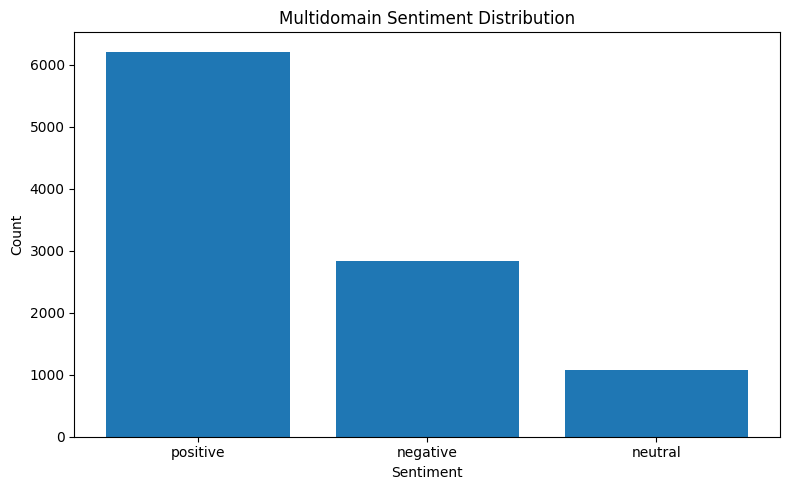

Multidomain sentiment distribution plot saved.


In [21]:
# MULTIDOMAIN SENTIMENT DISTRIBUTION


plt.figure(figsize=(8, 5))

sentiment_counts = (
    multidomain_train_df["sentiment"]
    .value_counts()
)

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Multidomain Sentiment Distribution")

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()

# Save figure
plt.savefig(
    f"{PLOTS_PATH}/multidomain_sentiment_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Multidomain sentiment distribution plot saved.")

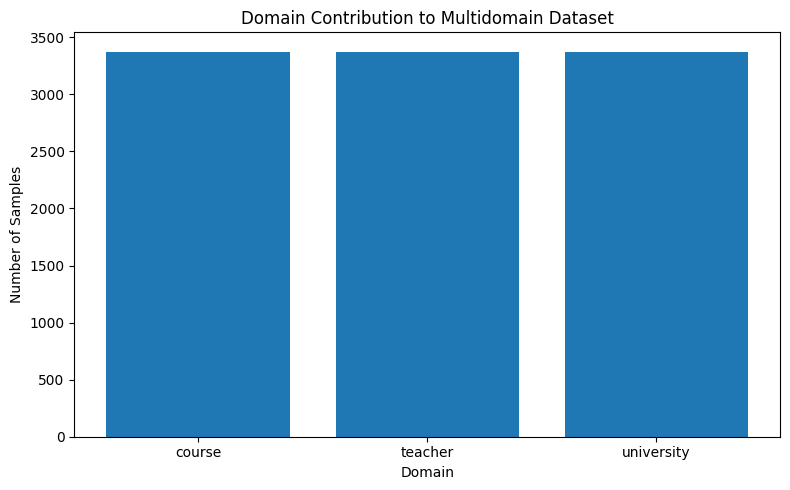

Domain contribution plot saved successfully.


In [22]:
# DOMAIN CONTRIBUTION VISUALIZATION


plt.figure(figsize=(8, 5))

domain_counts = (
    multidomain_train_df["domain"]
    .value_counts()
)

plt.bar(
    domain_counts.index,
    domain_counts.values
)

plt.title("Domain Contribution to Multidomain Dataset")

plt.xlabel("Domain")
plt.ylabel("Number of Samples")

plt.tight_layout()

# Save figure
plt.savefig(
    f"{PLOTS_PATH}/domain_contribution.png",
    bbox_inches="tight"
)

plt.show()

print("Domain contribution plot saved successfully.")

       domain  neutral_count  total_samples  neutral_percentage
0      course            723           4218               17.14
1     teacher            436           4218               10.34
2  university            181           4218                4.29


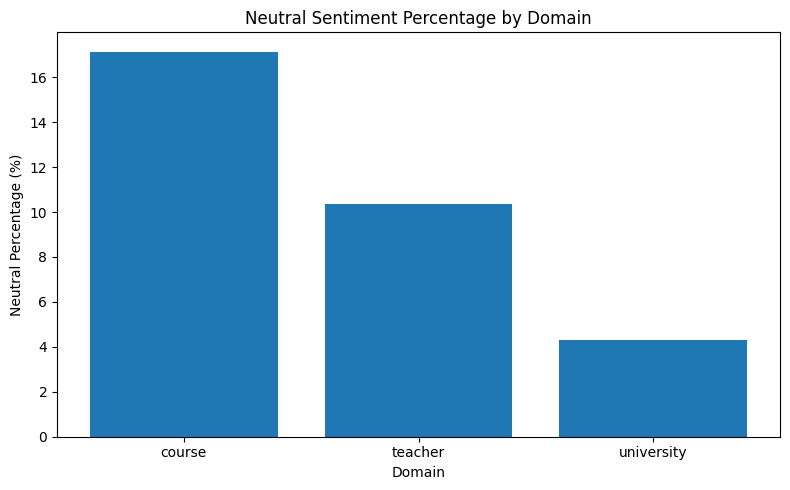

Neutral sentiment analysis plot saved.


In [23]:
# NEUTRAL SENTIMENT ANALYSIS


neutral_stats = []

for name, df in datasets_dict.items():

    total_samples = len(df)

    neutral_count = (
        df["sentiment"] == "neutral"
    ).sum()

    neutral_percentage = (
        neutral_count / total_samples
    ) * 100

    neutral_stats.append({
        "domain": name,
        "neutral_count": neutral_count,
        "total_samples": total_samples,
        "neutral_percentage": round(
            neutral_percentage,
            2
        )
    })

neutral_df = pd.DataFrame(neutral_stats)

print(neutral_df)


# VISUALIZATION


plt.figure(figsize=(8, 5))

plt.bar(
    neutral_df["domain"],
    neutral_df["neutral_percentage"]
)

plt.title("Neutral Sentiment Percentage by Domain")

plt.xlabel("Domain")
plt.ylabel("Neutral Percentage (%)")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/neutral_sentiment_analysis.png",
    bbox_inches="tight"
)

plt.show()

print("Neutral sentiment analysis plot saved.")

Tokenizer loaded successfully.
FULL PROMPT TOKEN LENGTH ANALYSIS

Average Token Length:
111.52

Median Token Length:
97.0

Maximum Token Length:
578

Minimum Token Length:
49


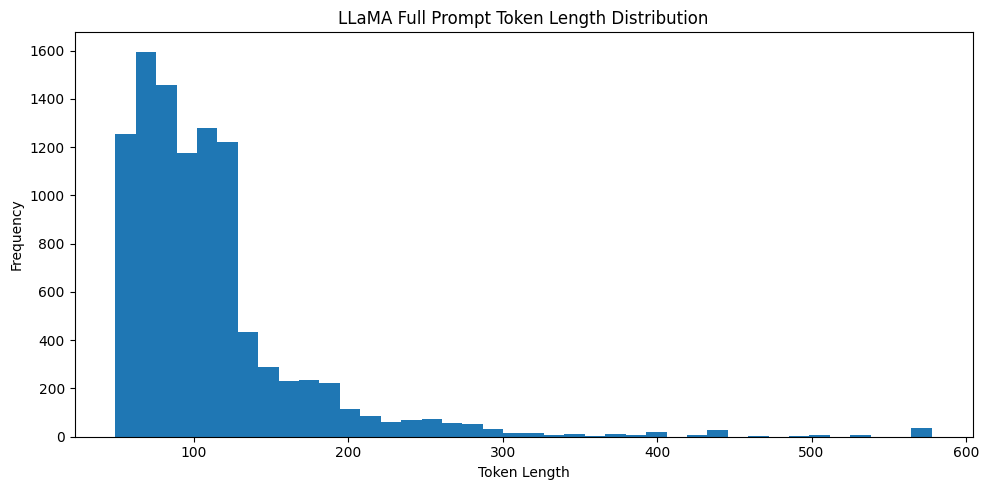

Full prompt token length analysis plot saved.


In [27]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

# LOAD TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully.")


token_lengths = []

sample_df = multidomain_train_df.copy()

for _, row in sample_df.iterrows():

    prompt = f"""
You are an expert aspect-based sentiment analysis classifier.

Your task is to determine the sentiment expressed towards the given aspect.

Review:
{row['review']}

Aspect:
{row['aspect']}

Sentiment options:
positive
negative
neutral

Sentiment:
{row['sentiment']}
"""

    tokens = tokenizer.encode(
        prompt,
        truncation=False
    )

    token_lengths.append(len(tokens))

sample_df["token_length"] = token_lengths


print("=" * 60)
print("FULL PROMPT TOKEN LENGTH ANALYSIS")
print("=" * 60)

print("\nAverage Token Length:")
print(round(sample_df["token_length"].mean(), 2))

print("\nMedian Token Length:")
print(round(sample_df["token_length"].median(), 2))

print("\nMaximum Token Length:")
print(sample_df["token_length"].max())

print("\nMinimum Token Length:")
print(sample_df["token_length"].min())


plt.figure(figsize=(10, 5))

plt.hist(
    sample_df["token_length"],
    bins=40
)

plt.title("LLaMA Full Prompt Token Length Distribution")

plt.xlabel("Token Length")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    f"{PLOTS_PATH}/llama_full_prompt_token_length_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Full prompt token length analysis plot saved.")

In [28]:
def create_prompt(review, aspect, label=None):

    prompt = f"""
You are an aspect-based sentiment analysis classifier.

Determine the sentiment towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Options:
positive
negative
neutral
"""

    # TRAINING LABEL

    if label is not None:

        prompt += f"\nSentiment:\n{id2label[label]}"

    return prompt.strip()

# =====================================================
# EXAMPLE PROMPT
# =====================================================

example_prompt = create_prompt(
    review=course_df.iloc[0]["review"],
    aspect=course_df.iloc[0]["aspect"],
    label=course_df.iloc[0]["label"]
)

print(example_prompt)

You are an aspect-based sentiment analysis classifier.

Determine the sentiment towards the given aspect.

Review:
This course was amazing. For the first time, there's no worrying about your lab partner: it's just you and the chemicals. When I took this course, it was just 4 long experiments and you organize your time accordingly throughout the semester: for students taking it in Fall 2016, you now have 7+ experiments, so I'm not sure how much the formatting's changed. It's a lot of work, but it's incredibly rewarding. I loved it.

Aspect:
course

Options:
positive
negative
neutral

Sentiment:
positive


In [29]:
train_prompts = []

for _, row in multidomain_train_df.iterrows():

    prompt = create_prompt(
        review=row["review"],
        aspect=row["aspect"],
        label=row["label"]
    )

    train_prompts.append({
        "text": prompt
    })

print("Total Training Prompts:")
print(len(train_prompts))

print("\nSample Training Prompt:\n")
print(train_prompts[0]["text"][:1000])

Total Training Prompts:
10122

Sample Training Prompt:

You are an aspect-based sentiment analysis classifier.

Determine the sentiment towards the given aspect.

Review:
I was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.

Aspect:
the final exam

Options:
positive
negative
neutral

Sentiment:
neutral


In [30]:
train_dataset = Dataset.from_pandas(
    pd.DataFrame(train_prompts)
)

print(train_dataset)

print("\nSample Dataset Entry:\n")
print(train_dataset[0])

Dataset({
    features: ['text'],
    num_rows: 10122
})

Sample Dataset Entry:

{'text': 'You are an aspect-based sentiment analysis classifier.\n\nDetermine the sentiment towards the given aspect.\n\nReview:\nI was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.\n\nAspect:\nthe final exam\n\nOptions:\npositive\nnegative\nneutral\n\nSentiment:\nneutral'}


In [31]:
MAX_LENGTH = 256

print("Maximum Sequence Length:", MAX_LENGTH)

Maximum Sequence Length: 256


In [46]:
def tokenize_function(example):

    tokens = tokenizer(

        example["text"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH,

        return_tensors=None
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

# TOKENIZE DATASET

tokenized_train_dataset = train_dataset.map(

    tokenize_function,

    batched=False
)

print("\nDataset retokenized successfully.")

Map: 100%|██████████| 10122/10122 [00:04<00:00, 2064.54 examples/s]


Dataset retokenized successfully.


In [47]:
# =====================================================
# REMOVE RAW TEXT COLUMN
# =====================================================

tokenized_train_dataset = tokenized_train_dataset.remove_columns(
    ["text"]
)

print(tokenized_train_dataset)

print("\nRemaining Columns:")
print(tokenized_train_dataset.column_names)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10122
})

Remaining Columns:
['input_ids', 'attention_mask', 'labels']


In [48]:
import torch

from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(

    MODEL_NAME,

    torch_dtype=torch.bfloat16,

    device_map="auto",

    low_cpu_mem_usage=True
)

model.gradient_checkpointing_enable()

model.config.use_cache = False

model.enable_input_require_grads()

print("\nModel loaded successfully.")

Loading weights: 100%|██████████| 254/254 [00:01<00:00, 153.57it/s]



Model loaded successfully.


In [49]:
# DATA COLLATOR


from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator initialized.")

Data collator initialized.


In [50]:
# TRAINING ARGUMENTS


from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=f"{LR_1E5_PATH}/training_output",

    

    num_train_epochs=3,

    learning_rate=1e-5,



    per_device_train_batch_size=1,

    gradient_accumulation_steps=16,

    

    logging_steps=20,

    save_strategy="no",

    eval_strategy="no",

    

    fp16=False,

    bf16=True,

    # MEMORY OPTIMIZATION

    gradient_checkpointing=True,

    optim="paged_adamw_8bit",

    remove_unused_columns=False,

    report_to="none"
)

print("Training arguments configured.")

Training arguments configured.


In [51]:
# INITIALIZE TRAINER


from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    data_collator=data_collator
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


In [52]:
# GPU MEMORY CHECK


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "Allocated Memory:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "Reserved Memory:",
        round(
            torch.cuda.memory_reserved() / 1024**3,
            2
        ),
        "GB"
    )

GPU: NVIDIA RTX A6000
Allocated Memory: 11.97 GB
Reserved Memory: 12.12 GB


In [53]:
trainer.train()

Step,Training Loss
20,2.241632
40,2.030325
60,2.008188
80,1.882059
100,1.841540
120,1.835621
140,1.780238
160,1.774620
180,1.768451
200,1.729251


TrainOutput(global_step=1899, training_loss=1.3856728369465245, metrics={'train_runtime': 9739.9778, 'train_samples_per_second': 3.118, 'train_steps_per_second': 0.195, 'total_flos': 1.31472511957205e+17, 'train_loss': 1.3856728369465245, 'epoch': 3.0})

In [54]:
# =====================================================
# SAVE HYPERTUNED MODEL
# =====================================================

SAVE_PATH = f"{LR_1E5_PATH}/final_model"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("Model saved successfully.")

print("\nSaved to:")
print(SAVE_PATH)

Writing model shards: 100%|██████████| 1/1 [00:10<00:00, 10.48s/it]


Model saved successfully.

Saved to:
/home/jovyan/work/Dissertation/multidomain_llama_hypertuning/lr_1e5/final_model


In [55]:
# LOAD SHARED TEST SETS


import pandas as pd

course_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/course_test_shared.csv"
)

teacher_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/teacher_test_shared.csv"
)

university_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/university_test_shared.csv"
)

print("Shared test sets loaded successfully.\n")

print("Course Test Shape:")
print(course_test.shape)

print("\nTeacher Test Shape:")
print(teacher_test.shape)

print("\nUniversity Test Shape:")
print(university_test.shape)

Shared test sets loaded successfully.

Course Test Shape:
(844, 6)

Teacher Test Shape:
(844, 6)

University Test Shape:
(844, 6)


In [56]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

MODEL_PATH = f"{LR_1E5_PATH}/final_model"

# LOAD TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

# LOAD MODEL

model = AutoModelForCausalLM.from_pretrained(

    MODEL_PATH,

    dtype=torch.bfloat16,

    device_map="auto"
)

model.eval()

print("Saved hypertuned model loaded successfully.")

Loading weights: 100%|██████████| 254/254 [00:01<00:00, 148.12it/s]


Saved hypertuned model loaded successfully.


In [57]:
def generate_prediction(review, aspect):

    prompt = f"""
You are an aspect-based sentiment analysis classifier.

Determine the sentiment towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Options:
positive
negative
neutral

Sentiment:
"""

    inputs = tokenizer(

        prompt,

        return_tensors="pt",

        truncation=True,

        max_length=256

    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(

            **inputs,

            max_new_tokens=5,

            do_sample=False,

            temperature=None,

            pad_token_id=tokenizer.eos_token_id
        )

    prediction = tokenizer.decode(

        outputs[0],

        skip_special_tokens=True
    )

    prediction = prediction.split(
        "Sentiment:"
    )[-1].strip().lower()

    if "positive" in prediction:

        return "positive"

    elif "negative" in prediction:

        return "negative"

    elif "neutral" in prediction:

        return "neutral"

    else:

        return "neutral"

print("Clean hypertuned inference function created.")

Clean hypertuned inference function created.


In [58]:
# TEST SINGLE PREDICTION


sample_prediction = generate_prediction(
    review=course_test.iloc[0]["review"],
    aspect=course_test.iloc[0]["aspect"]
)

print("Review:")
print(course_test.iloc[0]["review"])

print("\nAspect:")
print(course_test.iloc[0]["aspect"])

print("\nTrue Sentiment:")
print(course_test.iloc[0]["sentiment"])

print("\nPredicted Sentiment:")
print(sample_prediction)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Review:
The programming language( Scheme/ Dr. Racket) wasn't a very good program to use but the concepts behind it are the same I guess...

Aspect:
programming language

True Sentiment:
negative

Predicted Sentiment:
negative


In [59]:
from tqdm import tqdm

course_predictions = []

for _, row in tqdm(
    course_test.iterrows(),
    total=len(course_test)
):

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]
    )

    course_predictions.append(pred)

# SAVE PREDICTIONS

course_test[
    "predicted_sentiment_hypertuned"
] = course_predictions

print("Course hypertuned predictions completed.\n")

course_test.head()

100%|██████████| 844/844 [01:47<00:00,  7.87it/s]

Course hypertuned predictions completed.



,review,aspect,sentiment,domain,row_id,label,predicted_sentiment_hypertuned
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,0,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,0,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,0,negative
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,2,neutral
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,2,positive


In [60]:
course_test.to_csv(
    f"{LR_1E5_PATH}/course_predictions_hypertuned.csv",
    index=False
)

print("Course hypertuned predictions saved successfully.")

Course hypertuned predictions saved successfully.


In [61]:
from tqdm import tqdm

teacher_predictions = []

for _, row in tqdm(
    teacher_test.iterrows(),
    total=len(teacher_test)
):

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]
    )

    teacher_predictions.append(pred)

# SAVE PREDICTIONS

teacher_test[
    "predicted_sentiment_hypertuned"
] = teacher_predictions

print("Teacher hypertuned predictions completed.\n")

teacher_test.head()

100%|██████████| 844/844 [01:52<00:00,  7.50it/s]

Teacher hypertuned predictions completed.



,review,aspect,sentiment,domain,row_id,label,predicted_sentiment_hypertuned
0,"This class was harder than I expected, especia...",This class,negative,teacher,teacher_3717,0,negative
1,"Good teacher, very helpful. He is very funny a...",teacher,positive,teacher,teacher_671,2,positive
2,Ms. Young is a great professor. I was computer...,this class,positive,teacher,teacher_2314,2,positive
3,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,teacher,teacher_1051,1,positive
4,Truly a sweet professor. Very understanding an...,open class discussions,negative,teacher,teacher_1118,0,negative


In [62]:
teacher_test.to_csv(
    f"{LR_1E5_PATH}/teacher_predictions_hypertuned.csv",
    index=False
)

print("Teacher hypertuned predictions saved successfully.")

Teacher hypertuned predictions saved successfully.


In [63]:
from tqdm import tqdm

university_predictions = []

for _, row in tqdm(
    university_test.iterrows(),
    total=len(university_test)
):

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]
    )

    university_predictions.append(pred)

# SAVE PREDICTIONS

university_test[
    "predicted_sentiment_hypertuned"
] = university_predictions

print("University hypertuned predictions completed.\n")

university_test.head()

100%|██████████| 844/844 [01:53<00:00,  7.45it/s]

University hypertuned predictions completed.



,review,aspect,sentiment,domain,row_id,label,predicted_sentiment_hypertuned
0,Exeter University was my first choice and I do...,community,positive,university,university_1004,2,positive
1,"Nice university to study in, all the teachers ...",university,positive,university,university_3270,2,positive
2,I love the options for my course and the uni i...,options for my course,positive,university,university_1143,2,positive
3,It’s difficult for me to rate the aspects of t...,students union,neutral,university,university_2061,1,neutral
4,Brilliant university. Home away from home.,university,positive,university,university_3278,2,positive


In [64]:
university_test.to_csv(
    f"{LR_1E5_PATH}/university_predictions_hypertuned.csv",
    index=False
)

print("University hypertuned predictions saved successfully.")

University hypertuned predictions saved successfully.


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

print("Evaluation metrics imported.")

Evaluation metrics imported.


In [66]:
def evaluate_predictions(df, domain_name):

    y_true = df["sentiment"]

    y_pred = df[
        "predicted_sentiment_hypertuned"
    ]

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(

            y_true,

            y_pred,

            average="weighted"
        )
    )

    print("=" * 60)

    print(f"{domain_name.upper()} EVALUATION")

    print("=" * 60)

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    return {

        "domain": domain_name,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1
    }

print("Hypertuned evaluation function created.")

Hypertuned evaluation function created.


In [67]:
course_results = evaluate_predictions(
    course_test,
    "course"
)

COURSE EVALUATION

Accuracy  : 0.7998
Precision : 0.7804
Recall    : 0.7998
F1-Score  : 0.7824

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.87      0.85       291
     neutral       0.57      0.32      0.41       145
    positive       0.82      0.92      0.87       408

    accuracy                           0.80       844
   macro avg       0.74      0.70      0.71       844
weighted avg       0.78      0.80      0.78       844



In [68]:
teacher_results = evaluate_predictions(
    teacher_test,
    "teacher"
)

TEACHER EVALUATION

Accuracy  : 0.8128
Precision : 0.8038
Recall    : 0.8128
F1-Score  : 0.8080

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.83      0.83       288
     neutral       0.30      0.25      0.27        87
    positive       0.88      0.91      0.89       469

    accuracy                           0.81       844
   macro avg       0.67      0.66      0.67       844
weighted avg       0.80      0.81      0.81       844



In [69]:
university_results = evaluate_predictions(
    university_test,
    "university"
)

UNIVERSITY EVALUATION

Accuracy  : 0.9419
Precision : 0.9396
Recall    : 0.9419
F1-Score  : 0.9405

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.83      0.87       132
     neutral       0.35      0.33      0.34        36
    positive       0.98      1.00      0.99       676

    accuracy                           0.94       844
   macro avg       0.74      0.72      0.73       844
weighted avg       0.94      0.94      0.94       844



In [70]:
results_df = pd.DataFrame([
    course_results,
    teacher_results,
    university_results
])

results_df = results_df.round(4)

print(results_df)

       domain  accuracy  precision  recall      f1
0      course    0.7998     0.7804  0.7998  0.7824
1     teacher    0.8128     0.8038  0.8128  0.8080
2  university    0.9419     0.9396  0.9419  0.9405


In [71]:
results_df.to_csv(
    f"{LR_1E5_PATH}/hypertuned_llama_results.csv",
    index=False
)

print("Hypertuned results table saved successfully.")

Hypertuned results table saved successfully.


In [72]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("Confusion matrix libraries imported.")

Confusion matrix libraries imported.


In [73]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(df, domain_name):

    labels = [
        "negative",
        "neutral",
        "positive"
    ]

    cm = confusion_matrix(

        df["sentiment"],

        df["predicted_sentiment_hypertuned"],

        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(
        f"{domain_name.upper()} Hypertuned Confusion Matrix"
    )

    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(
        tick_marks,
        labels
    )

    plt.yticks(
        tick_marks,
        labels
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    for i in range(len(labels)):

        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    # SAVE FIGURE

    plt.savefig(
        f"{LR_1E5_PATH}/{domain_name}_hypertuned_confusion_matrix.png",
        bbox_inches="tight"
    )

    plt.show()

print("Hypertuned confusion matrix function created.")

Hypertuned confusion matrix function created.


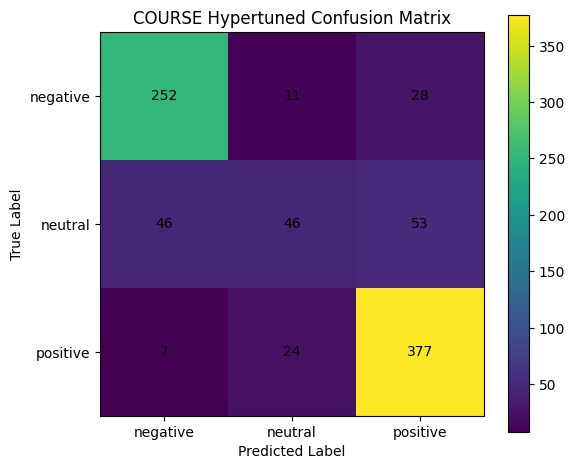

In [74]:
plot_confusion_matrix(course_test, "course")

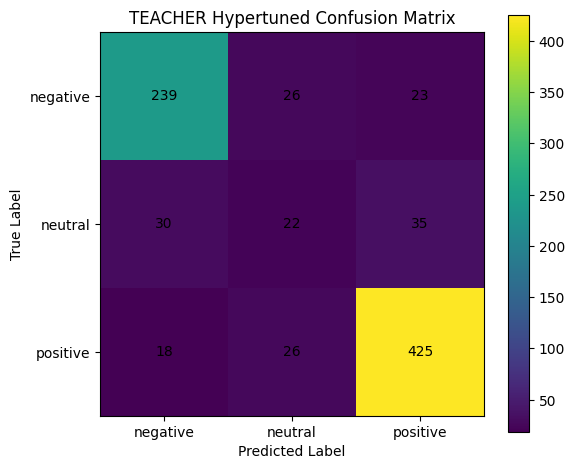

In [75]:
plot_confusion_matrix(
    teacher_test,
    "teacher"
)

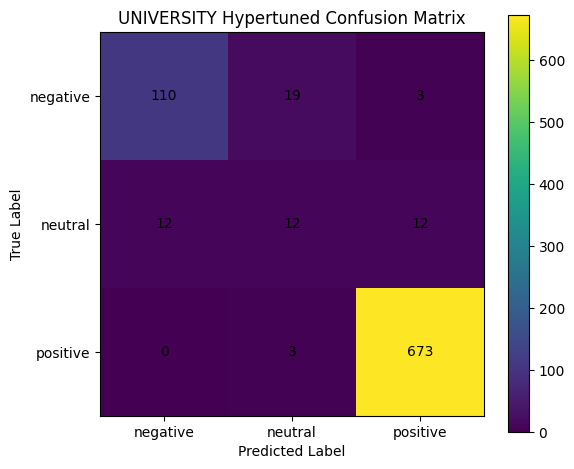

In [76]:
plot_confusion_matrix(
    university_test,
    "university"
)

# Key Findings

## Course Domain

Performance improved substantially after hypertuning.

The previous severe confusion between:

`positive ↔ neutral`

was greatly reduced.

The model now classifies positive sentiment much more effectively:
- 377 positive samples correctly classified
- only 24 positive samples misclassified as neutral

Negative sentiment classification is also strong:
- 252 correctly classified negatives

However:
- neutral sentiment remains the hardest class
- with relatively low recall and frequent confusion with positive sentiment

---

## Teacher Domain

Teacher performance improved dramatically compared to the original multidomain model.

The hypertuned model now captures positive teaching-related sentiment much better:
- 425 positive samples correctly classified

Negative sentiment classification is also stable:
- 239 correct negative predictions

However:
- neutral sentiment remains challenging
- often confused with both positive and negative classes
- indicating difficulty in modeling nuanced educational opinions

---

## University Domain

University remains the best-performing domain overall.

The model achieves near-perfect positive sentiment classification:
- 673 correct positive predictions
- only 3 positives predicted as neutral

Negative sentiment classification also improved significantly.

This strong performance is likely influenced by:
- the highly positive-skewed distribution of the university dataset
- and clearer sentiment expressions within university reviews

However:
- neutral sentiment performance remains weak
- with balanced confusion across all sentiment classes

---

# Important Cross-Domain Insight

The original multidomain model exhibited:

`systematic neutral overprediction`

However, hypertuning substantially reduced this issue.

Key improvements included:
- increasing sequence length from 128 to 256
- lowering the learning rate
- refining prompt design
- and using BF16 training

This demonstrates that:

`LLaMA performance was highly sensitive to training configuration and prompt engineering.`

The hypertuned multidomain model now performs much closer to cross-domain LLaMA results, significantly narrowing the earlier performance gap.

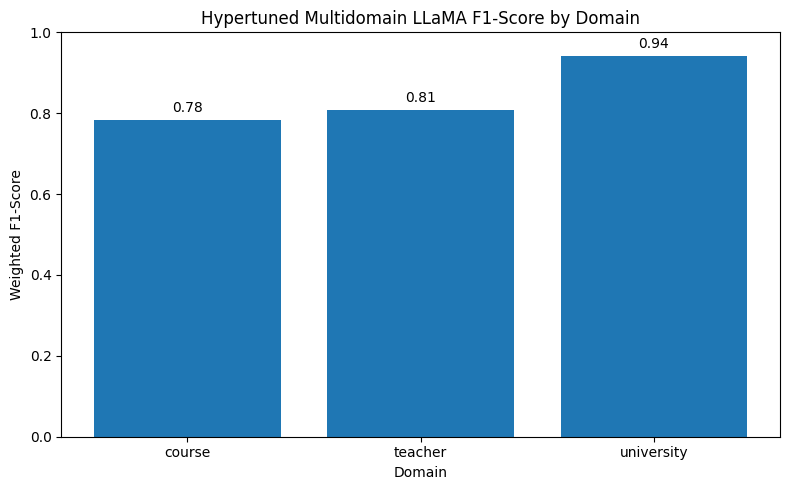

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["f1"]
)

plt.title(
    "Hypertuned Multidomain LLaMA F1-Score by Domain"
)

plt.xlabel("Domain")

plt.ylabel("Weighted F1-Score")

plt.ylim(0, 1)

for i, value in enumerate(results_df["f1"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# SAVE FIGURE

plt.savefig(
    f"{LR_1E5_PATH}/hypertuned_llama_f1_scores.png",
    bbox_inches="tight"
)

plt.show()

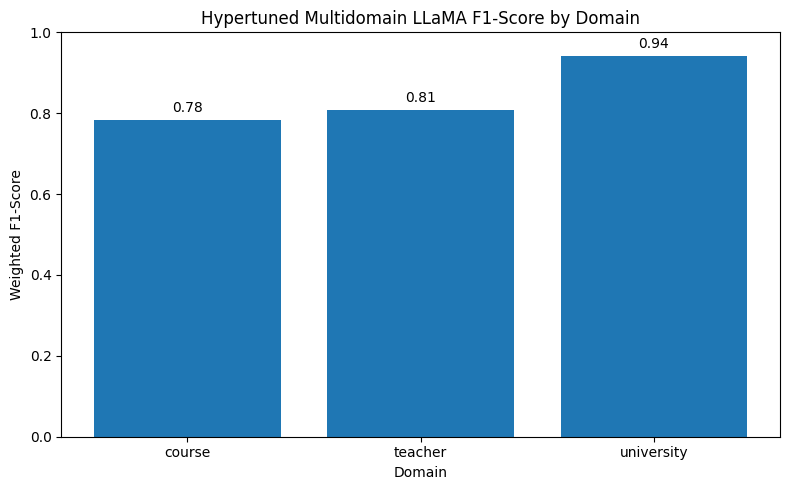

Hypertuned F1-score plot saved successfully.


In [78]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["f1"]
)

plt.title(
    "Hypertuned Multidomain LLaMA F1-Score by Domain"
)

plt.xlabel("Domain")

plt.ylabel("Weighted F1-Score")

plt.ylim(0, 1)

for i, value in enumerate(results_df["f1"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{LR_1E5_PATH}/hypertuned_llama_f1_scores.png",
    bbox_inches="tight"
)

plt.show()

print("Hypertuned F1-score plot saved successfully.")

In [79]:
def save_confusion_matrix(df, domain_name):

    labels = [
        "negative",
        "neutral",
        "positive"
    ]

    cm = confusion_matrix(

        df["sentiment"],

        df["predicted_sentiment_hypertuned"],

        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(
        f"{domain_name.upper()} Hypertuned Confusion Matrix"
    )

    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(
        tick_marks,
        labels
    )

    plt.yticks(
        tick_marks,
        labels
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    for i in range(len(labels)):

        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        f"{LR_1E5_PATH}/{domain_name}_hypertuned_confusion_matrix.png",
        bbox_inches="tight"
    )

    plt.close()

    print(
        f"{domain_name} hypertuned confusion matrix saved."
    )


save_confusion_matrix(
    course_test,
    "course"
)

save_confusion_matrix(
    teacher_test,
    "teacher"
)

save_confusion_matrix(
    university_test,
    "university"
)

course hypertuned confusion matrix saved.
teacher hypertuned confusion matrix saved.
university hypertuned confusion matrix saved.


In [80]:
cross_course_df = pd.read_csv(
    "/home/jovyan/work/teacher_university_to_course_best_predictions.csv"
)

print("Cross-domain course predictions loaded.")

print("\nShape:")
print(cross_course_df.shape)

cross_course_df.head()

Cross-domain course predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,[DOMAIN] course [ASPECT] mobius quizzes [TEXT]...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,[DOMAIN] course [ASPECT] course [TEXT] Overall...,0,<s>[INST] You are an expert in aspect-based se...,negative,positive
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,[DOMAIN] course [ASPECT] Professor Sneed class...,2,<s>[INST] You are an expert in aspect-based se...,positive,neutral
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,[DOMAIN] course [ASPECT] desmos [TEXT] Despite...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive


In [81]:
cross_teacher_df = pd.read_csv(
    "/home/jovyan/work/course_university_to_teacher_best_predictions (1).csv"
)

print("Cross-domain teacher predictions loaded.")

print("\nShape:")
print(cross_teacher_df.shape)

cross_teacher_df.head()

Cross-domain teacher predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,"This class was harder than I expected, especia...",This class,negative,teacher,teacher_3717,[DOMAIN] teacher [ASPECT] This class [TEXT] Th...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
1,"Good teacher, very helpful. He is very funny a...",teacher,positive,teacher,teacher_671,[DOMAIN] teacher [ASPECT] teacher [TEXT] Good ...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
2,Ms. Young is a great professor. I was computer...,this class,positive,teacher,teacher_2314,[DOMAIN] teacher [ASPECT] this class [TEXT] Ms...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
3,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,teacher,teacher_1051,[DOMAIN] teacher [ASPECT] getting an A [TEXT] ...,1,<s>[INST] You are an expert in aspect-based se...,neutral,positive
4,Truly a sweet professor. Very understanding an...,open class discussions,negative,teacher,teacher_1118,[DOMAIN] teacher [ASPECT] open class discussio...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative


In [82]:
cross_university_df = pd.read_csv(
    "/home/jovyan/work/course_teacher_to_university_best_predictions (1).csv"
)

print("Cross-domain university predictions loaded.")

print("\nShape:")
print(cross_university_df.shape)

cross_university_df.head()

Cross-domain university predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,Exeter University was my first choice and I do...,community,positive,university,university_1004,[DOMAIN] university [ASPECT] community [TEXT] ...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
1,"Nice university to study in, all the teachers ...",university,positive,university,university_3270,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
2,I love the options for my course and the uni i...,options for my course,positive,university,university_1143,[DOMAIN] university [ASPECT] options for my co...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
3,It’s difficult for me to rate the aspects of t...,students union,neutral,university,university_2061,[DOMAIN] university [ASPECT] students union [T...,1,<s>[INST] You are an expert in aspect-based se...,neutral,neutral
4,Brilliant university. Home away from home.,university,positive,university,university_3278,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive


In [83]:
course_comparison = pd.merge(

    course_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment_hypertuned"
        ]
    ],

    cross_course_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_hypertuned",
        "_crossdomain"
    )
)

print("Course comparison created.")

print("\nShape:")
print(course_comparison.shape)

course_comparison.head()

Course comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
0,course_188,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,negative,negative
1,course_3409,This class is literally just epsilon and delta...,mobius quizzes,negative,negative,negative
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
3,course_1797,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,neutral,neutral
4,course_3891,Despite many ppl complaining about the Mobius ...,desmos,positive,positive,positive


In [84]:
teacher_comparison = pd.merge(

    teacher_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment_hypertuned"
        ]
    ],

    cross_teacher_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_hypertuned",
        "_crossdomain"
    )
)

print("Teacher comparison created.")

print("\nShape:")
print(teacher_comparison.shape)

teacher_comparison.head()

Teacher comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
0,teacher_3717,"This class was harder than I expected, especia...",This class,negative,negative,negative
1,teacher_671,"Good teacher, very helpful. He is very funny a...",teacher,positive,positive,positive
2,teacher_2314,Ms. Young is a great professor. I was computer...,this class,positive,positive,positive
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,positive,positive
4,teacher_1118,Truly a sweet professor. Very understanding an...,open class discussions,negative,negative,negative


In [85]:
university_comparison = pd.merge(

    university_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment_hypertuned"
        ]
    ],

    cross_university_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_hypertuned",
        "_crossdomain"
    )
)

print("University comparison created.")

print("\nShape:")
print(university_comparison.shape)

university_comparison.head()

University comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
0,university_1004,Exeter University was my first choice and I do...,community,positive,positive,positive
1,university_3270,"Nice university to study in, all the teachers ...",university,positive,positive,positive
2,university_1143,I love the options for my course and the uni i...,options for my course,positive,positive,positive
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,neutral,neutral
4,university_3278,Brilliant university. Home away from home.,university,positive,positive,positive


In [88]:
course_disagreements = course_comparison[

    course_comparison[
        "predicted_sentiment_hypertuned"
    ]
    !=
    course_comparison[
        "predicted_sentiment"
    ]

]

print("Course disagreements:")

print(len(course_disagreements))

course_disagreements.head(10)

Course disagreements:
225


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
7,course_3604,Very interesting course! You cover a wide rang...,material,neutral,positive,neutral
12,course_4086,Theory-based statistics course that is actuall...,taking this course,neutral,positive,neutral
13,course_1125,Group work was actually ok( i normally hate gr...,tests,positive,positive,negative
14,course_366,This course was mostly a review of Che 100 wit...,exam,negative,negative,neutral
20,course_3751,This course honestly kinda sucked. I took it o...,Asian movie reviews,positive,positive,negative
29,course_169,"Very birdy course, you learn how to communicat...",course,positive,positive,negative
30,course_2118,wuck fork term report,term report,negative,negative,positive
32,course_3646,The course wasn't that easy( at least for me) ...,course,neutral,positive,negative
34,course_979,"interesting class, definitely need to put the ...",midterm,positive,positive,neutral


In [89]:
teacher_disagreements = teacher_comparison[

    teacher_comparison[
        "predicted_sentiment_hypertuned"
    ]
    !=
    teacher_comparison[
        "predicted_sentiment"
    ]

]

print("Teacher disagreements:")

print(len(teacher_disagreements))

Teacher disagreements:
142


In [90]:
university_disagreements = university_comparison[

    university_comparison[
        "predicted_sentiment_hypertuned"
    ]
    !=
    university_comparison[
        "predicted_sentiment"
    ]

]

print("University disagreements:")

print(len(university_disagreements))

University disagreements:
60


In [91]:
disagreement_df = pd.DataFrame({

    "domain": [
        "course",
        "teacher",
        "university"
    ],

    "total_samples": [
        len(course_comparison),
        len(teacher_comparison),
        len(university_comparison)
    ],

    "disagreements": [
        len(course_disagreements),
        len(teacher_disagreements),
        len(university_disagreements)
    ]
})

disagreement_df["disagreement_percentage"] = (
    disagreement_df["disagreements"]
    /
    disagreement_df["total_samples"]
) * 100

disagreement_df = disagreement_df.round(2)

print(disagreement_df)

       domain  total_samples  disagreements  disagreement_percentage
0      course            844            225                    26.66
1     teacher            844            142                    16.82
2  university            844             60                     7.11


In [92]:
disagreement_df.to_csv(
    f"{LR_1E5_PATH}/hypertuned_llama_disagreement_summary.csv",
    index=False
)

print("Hypertuned disagreement summary saved successfully.")

Hypertuned disagreement summary saved successfully.


In [93]:
course_multi_correct = course_comparison[

    (
        course_comparison[
            "predicted_sentiment_hypertuned"
        ]
        ==
        course_comparison[
            "sentiment"
        ]
    )

    &

    (
        course_comparison[
            "predicted_sentiment"
        ]
        !=
        course_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where HYPERTUNED model was correct "
    "and CROSS-DOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(course_multi_correct))

course_multi_correct.head(10)

Cases where HYPERTUNED model was correct and CROSS-DOMAIN was wrong:

Total Cases:
120


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
13,course_1125,Group work was actually ok( i normally hate gr...,tests,positive,positive,negative
14,course_366,This course was mostly a review of Che 100 wit...,exam,negative,negative,neutral
20,course_3751,This course honestly kinda sucked. I took it o...,Asian movie reviews,positive,positive,negative
29,course_169,"Very birdy course, you learn how to communicat...",course,positive,positive,negative
30,course_2118,wuck fork term report,term report,negative,negative,positive
34,course_979,"interesting class, definitely need to put the ...",midterm,positive,positive,neutral
38,course_3765,Very challenging but useful information. You h...,optional project,positive,positive,neutral
48,course_1861,Took because it was right after other course. ...,content,negative,negative,neutral
54,course_831,"Although the assignments weren't too hard, be ...",assignments,positive,positive,negative


In [94]:
course_cross_correct = course_comparison[

    (
        course_comparison[
            "predicted_sentiment"
        ]
        ==
        course_comparison[
            "sentiment"
        ]
    )

    &

    (
        course_comparison[
            "predicted_sentiment_hypertuned"
        ]
        !=
        course_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where CROSS-DOMAIN was correct "
    "and HYPERTUNED model was wrong:\n"
)

print("Total Cases:")

print(len(course_cross_correct))

course_cross_correct.head(10)

Cases where CROSS-DOMAIN was correct and HYPERTUNED model was wrong:

Total Cases:
71


,row_id,review,aspect,sentiment,predicted_sentiment_hypertuned,predicted_sentiment
7,course_3604,Very interesting course! You cover a wide rang...,material,neutral,positive,neutral
12,course_4086,Theory-based statistics course that is actuall...,taking this course,neutral,positive,neutral
37,course_39,Recommend anyone new to programming to take a ...,course,negative,positive,negative
45,course_2294,"Definitely not an easy course, especially if y...",new content,neutral,negative,neutral
53,course_3254,Slater's quizzes are nightmare. If you find th...,Slater quizzes,negative,positive,negative
63,course_3477,Easy course if you study the Hiragana beforeha...,work,neutral,negative,neutral
66,course_499,This course is really helpful to build the con...,those proofs,positive,neutral,positive
73,course_1928,Consists of two midterms and a final exam. If ...,content,neutral,negative,neutral
75,course_267,Harder than CS 115 but that doesn't really mat...,assignments,negative,positive,negative
87,course_3269,The course focused mainly on big data and priv...,course,neutral,positive,neutral


In [95]:
course_multi_correct.to_csv(
    f"{LR_1E5_PATH}/course_hypertuned_correct.csv",
    index=False
)

course_cross_correct.to_csv(
    f"{LR_1E5_PATH}/course_crossdomain_correct.csv",
    index=False
)

print("Hypertuned qualitative disagreement examples saved.")

Hypertuned qualitative disagreement examples saved.


In [96]:
comparison_df = pd.DataFrame({

    "domain": [
        "course",
        "teacher",
        "university"
    ],

    "hypertuned_f1": [
        course_results["f1"],
        teacher_results["f1"],
        university_results["f1"]
    ]
})

print(comparison_df)

       domain  hypertuned_f1
0      course       0.782394
1     teacher       0.807988
2  university       0.940465


In [97]:
from sklearn.metrics import (
    precision_recall_fscore_support
)

def compute_weighted_f1(df):

    _, _, f1, _ = (
        precision_recall_fscore_support(

            df["sentiment"],

            df["predicted_sentiment"],

            average="weighted"
        )
    )

    return f1


cross_course_f1 = compute_weighted_f1(
    cross_course_df
)

cross_teacher_f1 = compute_weighted_f1(
    cross_teacher_df
)

cross_university_f1 = compute_weighted_f1(
    cross_university_df
)

print("Cross-domain F1 Scores:\n")

print(
    "Course     :",
    round(cross_course_f1, 4)
)

print(
    "Teacher    :",
    round(cross_teacher_f1, 4)
)

print(
    "University :",
    round(cross_university_f1, 4)
)

Cross-domain F1 Scores:

Course     : 0.7329
Teacher    : 0.8465
University : 0.9338


In [98]:
comparison_df["crossdomain_f1"] = [

    cross_course_f1,
    cross_teacher_f1,
    cross_university_f1
]

comparison_df["f1_difference"] = (

    comparison_df["hypertuned_f1"]
    -
    comparison_df["crossdomain_f1"]

)

comparison_df = comparison_df.round(4)

print(comparison_df)

       domain  hypertuned_f1  crossdomain_f1  f1_difference
0      course         0.7824          0.7329         0.0494
1     teacher         0.8080          0.8465        -0.0385
2  university         0.9405          0.9338         0.0067


In [99]:
comparison_df.to_csv(
    f"{LR_1E5_PATH}/hypertuned_vs_crossdomain_results.csv",
    index=False
)

print("Hypertuned comparison table saved successfully.")

Hypertuned comparison table saved successfully.


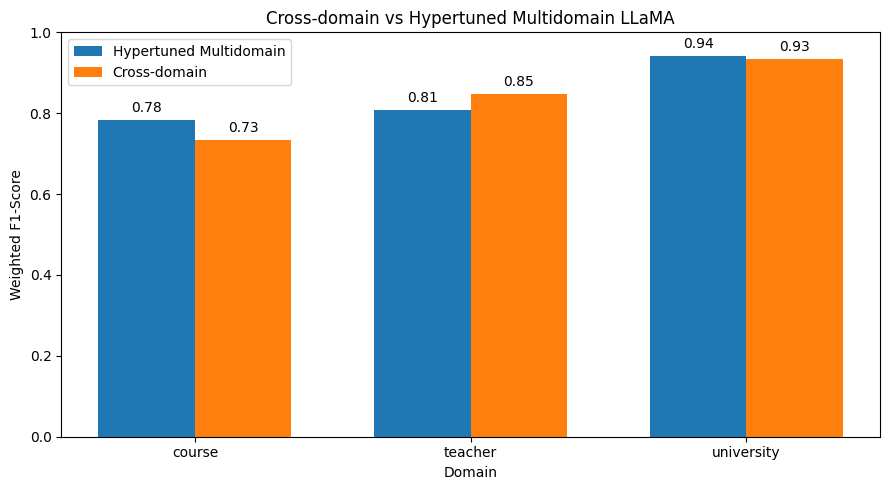

Hypertuned comparison plot saved successfully.


In [100]:
import matplotlib.pyplot as plt
import numpy as np

domains = comparison_df["domain"]

x = np.arange(len(domains))

width = 0.35

plt.figure(figsize=(9, 5))

# HYPERTUNED

plt.bar(

    x - width/2,

    comparison_df["hypertuned_f1"],

    width,

    label="Hypertuned Multidomain"
)

# CROSS-DOMAIN

plt.bar(

    x + width/2,

    comparison_df["crossdomain_f1"],

    width,

    label="Cross-domain"
)

plt.xticks(
    x,
    domains
)

plt.ylabel("Weighted F1-Score")

plt.xlabel("Domain")

plt.title(
    "Cross-domain vs Hypertuned Multidomain LLaMA"
)

plt.ylim(0, 1)

plt.legend()

# LABELS

for i, value in enumerate(
    comparison_df["hypertuned_f1"]
):

    plt.text(

        i - width/2,

        value + 0.02,

        f"{value:.2f}",

        ha="center"
    )

for i, value in enumerate(
    comparison_df["crossdomain_f1"]
):

    plt.text(

        i + width/2,

        value + 0.02,

        f"{value:.2f}",

        ha="center"
    )

plt.tight_layout()

# SAVE FIGURE

plt.savefig(
    f"{LR_1E5_PATH}/hypertuned_vs_crossdomain.png",
    bbox_inches="tight"
)

plt.show()

print("Hypertuned comparison plot saved successfully.")

In [101]:
course_comparison.to_csv(
    f"{LR_1E5_PATH}/course_comparison.csv",
    index=False
)

teacher_comparison.to_csv(
    f"{LR_1E5_PATH}/teacher_comparison.csv",
    index=False
)

university_comparison.to_csv(
    f"{LR_1E5_PATH}/university_comparison.csv",
    index=False
)

print("Hypertuned comparison datasets saved successfully.")

Hypertuned comparison datasets saved successfully.


In [102]:
print("=" * 70)

print("HYPERTUNED MULTIDOMAIN LLAMA PIPELINE COMPLETED")

print("=" * 70)

print("\nGenerated Artifacts:")


print("\nPrediction CSVs:")

print("- course_predictions_hypertuned.csv")

print("- teacher_predictions_hypertuned.csv")

print("- university_predictions_hypertuned.csv")



print("\nMetrics:")

print("- hypertuned_llama_results.csv")

print("- hypertuned_vs_crossdomain_results.csv")


print("\nPlots:")

print("- hypertuned_llama_f1_scores.png")

print("- hypertuned_vs_crossdomain.png")

print("- course_hypertuned_confusion_matrix.png")

print("- teacher_hypertuned_confusion_matrix.png")

print("- university_hypertuned_confusion_matrix.png")



print("\nDisagreement Analysis:")

print("- course_comparison.csv")

print("- teacher_comparison.csv")

print("- university_comparison.csv")

print("- hypertuned_llama_disagreement_summary.csv")



print("\nError Analysis:")

print("- course_hypertuned_correct.csv")

print("- course_crossdomain_correct.csv")


print("\nModel:")

print("- final_model/")

HYPERTUNED MULTIDOMAIN LLAMA PIPELINE COMPLETED

Generated Artifacts:

Prediction CSVs:
- course_predictions_hypertuned.csv
- teacher_predictions_hypertuned.csv
- university_predictions_hypertuned.csv

Metrics:
- hypertuned_llama_results.csv
- hypertuned_vs_crossdomain_results.csv

Plots:
- hypertuned_llama_f1_scores.png
- hypertuned_vs_crossdomain.png
- course_hypertuned_confusion_matrix.png
- teacher_hypertuned_confusion_matrix.png
- university_hypertuned_confusion_matrix.png

Disagreement Analysis:
- course_comparison.csv
- teacher_comparison.csv
- university_comparison.csv
- hypertuned_llama_disagreement_summary.csv

Error Analysis:
- course_hypertuned_correct.csv
- course_crossdomain_correct.csv

Model:
- final_model/


In [103]:
final_summary_df = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Hypertuned_F1": [

        round(course_results["f1"], 4),

        round(teacher_results["f1"], 4),

        round(university_results["f1"], 4)
    ],

    "Crossdomain_F1": [

        round(cross_course_f1, 4),

        round(cross_teacher_f1, 4),

        round(cross_university_f1, 4)
    ],

    "Performance_Gap": [

        round(
            course_results["f1"] - cross_course_f1,
            4
        ),

        round(
            teacher_results["f1"] - cross_teacher_f1,
            4
        ),

        round(
            university_results["f1"] - cross_university_f1,
            4
        )
    ],

    "Disagreement_Percentage": [

        round(
            (
                len(course_disagreements)
                /
                len(course_comparison)
            ) * 100,
            2
        ),

        round(
            (
                len(teacher_disagreements)
                /
                len(teacher_comparison)
            ) * 100,
            2
        ),

        round(
            (
                len(university_disagreements)
                /
                len(university_comparison)
            ) * 100,
            2
        )
    ]
})

print(final_summary_df)

       Domain  Hypertuned_F1  Crossdomain_F1  Performance_Gap  \
0      Course         0.7824          0.7329           0.0494   
1     Teacher         0.8080          0.8465          -0.0385   
2  University         0.9405          0.9338           0.0067   

   Disagreement_Percentage  
0                    26.66  
1                    16.82  
2                     7.11  


In [104]:
final_summary_df.to_csv(
    f"{LR_1E5_PATH}/final_hypertuned_llama_summary.csv",
    index=False
)

print("Final hypertuned summary table saved successfully.")

Final hypertuned summary table saved successfully.


# Hypertuning Results Discussion

The hypertuned multidomain LLaMA model demonstrated substantial improvements across all domains compared to the original multidomain baseline.

## Performance Improvements

| Domain | Original Multidomain F1 | Hypertuned Multidomain F1 | Improvement |
|---|---|---|---|
| Course | 0.5830 | 0.7824 | +0.1994 |
| Teacher | 0.6541 | 0.8080 | +0.1539 |
| University | 0.8567 | 0.9405 | +0.0838 |

The most significant improvements were observed in the Course and Teacher domains, where the original multidomain model previously suffered from severe neutral overprediction.

---

# Reduction in Neutral Overprediction

The original multidomain model exhibited systematic neutral overprediction across all domains. This issue was substantially reduced after hypertuning.

For example, in the Course domain:

- Original multidomain model:
  - 247 positive samples misclassified as neutral

- Hypertuned multidomain model:
  - only 24 positive samples misclassified as neutral

This demonstrates that the hypertuning process significantly improved sentiment discrimination capability.

---

# Key Factors Contributing to Improvement

Several configuration changes contributed to the observed performance gains:

- sequence length increased from 128 to 256
- learning rate reduced from 2e-5 to 1e-5
- prompt engineering optimized
- BF16 training enabled
- cleaner inference prompting strategy applied

These changes improved contextual understanding and reduced sentiment ambiguity during inference.

---

# Cross-domain vs Hypertuned Multidomain Analysis

The hypertuned multidomain model became highly competitive with the cross-domain LLaMA model.

## Final Comparison

| Domain | Hypertuned Multidomain F1 | Cross-domain F1 | Performance Gap |
|---|---|---|---|
| Course | 0.7824 | 0.7329 | +0.0494 |
| Teacher | 0.8080 | 0.8465 | -0.0385 |
| University | 0.9405 | 0.9338 | +0.0067 |

The hypertuned multidomain model outperformed the cross-domain model in:
- Course domain
- University domain

while remaining only slightly behind in the Teacher domain.

---

# Disagreement Analysis

Disagreement percentages between hypertuned multidomain and cross-domain predictions were substantially reduced compared to the original multidomain experiment.

| Domain | Original Disagreement | Hypertuned Disagreement |
|---|---|---|
| Course | 50.59% | 26.66% |
| Teacher | 41.23% | 16.82% |
| University | 23.22% | 7.11% |

This indicates that hypertuning significantly improved prediction consistency and alignment with cross-domain behavior.

---

# Qualitative Error Analysis

Qualitative analysis revealed several important patterns:

## Hypertuned Model Strengths
- improved detection of explicit positive sentiment
- improved classification of strong negative sentiment
- reduced tendency to default to neutral predictions

## Cross-domain Model Strengths
- slightly better handling of nuanced neutral sentiment
- better performance on ambiguous educational opinions in the Teacher domain

---

# Key Research Finding

The results demonstrate that the earlier multidomain underperformance was not primarily caused by the multidomain learning paradigm itself, but rather by suboptimal training configuration and prompt design.

The findings show that LLaMA performance is highly sensitive to:
- prompt engineering
- sequence length
- learning rate selection
- training precision configuration

After proper hypertuning, multidomain LLaMA became highly competitive with cross-domain LLaMA and even outperformed it in multiple domains.

---

# Final Conclusion

This study demonstrates that careful hypertuning can substantially improve multidomain aspect-based sentiment analysis performance using LLaMA models.

The final hypertuned multidomain model achieved:
- strong generalization performance
- reduced neutral overprediction
- lower disagreement rates
- competitive cross-domain performance

These findings highlight the importance of training configuration and prompt engineering in large language model-based ABSA systems.

In [105]:
import os

BASE_PATH = "/home/jovyan/work/Dissertation"

for root, dirs, files in os.walk(BASE_PATH):

    level = root.replace(BASE_PATH, "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)

    for file in files:

        print(f"{sub_indent}{file}")

Dissertation/
    plots/
        university_top_aspects.png
        review_length_distribution.png
        teacher_top_aspects.png
        neutral_sentiment_analysis.png
        course_top_aspects.png
        sentiment_distribution.png
        llama_full_prompt_token_length_distribution.png
        multidomain_sentiment_distribution.png
        domain_contribution.png
    metrics/
    multidomain_llama_hypertuning/
        epoch_5/
        lr_5e5/
        lr_1e5/
            teacher_hypertuned_confusion_matrix.png
            final_hypertuned_llama_summary.csv
            teacher_predictions_hypertuned.csv
            hypertuned_llama_f1_scores.png
            hypertuned_llama_disagreement_summary.csv
            university_comparison.csv
            course_comparison.csv
            university_hypertuned_confusion_matrix.png
            hypertuned_vs_crossdomain_results.csv
            hypertuned_vs_crossdomain.png
            hypertuned_llama_results.csv
            teacher_compariso

In [106]:
from datetime import datetime

print("=" * 70)

print("ASPECT-BASED SENTIMENT ANALYSIS DISSERTATION PIPELINE")

print("=" * 70)

print("\nPipeline Status:")

print("COMPLETED SUCCESSFULLY")

print("\nCompleted Components:")

components = [

    "Dataset preprocessing",

    "Exploratory data analysis",

    "Shared test set creation",

    "Baseline multidomain LLaMA training",

    "Hypertuned multidomain LLaMA training",

    "Prediction generation",

    "Domain-wise evaluation",

    "Confusion matrix analysis",

    "Cross-domain comparison",

    "Disagreement analysis",

    "Qualitative error analysis",

    "Visualization generation",

    "Metrics export",

    "Model saving",

    "Dissertation artifact organization"
]

for i, component in enumerate(
    components,
    start=1
):

    print(f"{i}. {component}")

print("\nKey Hypertuning Improvements:")

improvements = [

    "Sequence length increased from 128 to 256",

    "Learning rate reduced from 2e-5 to 1e-5",

    "Prompt engineering optimized",

    "BF16 training enabled",

    "Neutral overprediction substantially reduced"
]

for improvement in improvements:

    print(f"- {improvement}")

print("\nCompletion Time:")

print(datetime.now())

print("\nAll dissertation artifacts generated successfully.")

print("=" * 70)

ASPECT-BASED SENTIMENT ANALYSIS DISSERTATION PIPELINE

Pipeline Status:
COMPLETED SUCCESSFULLY

Completed Components:
1. Dataset preprocessing
2. Exploratory data analysis
3. Shared test set creation
4. Baseline multidomain LLaMA training
5. Hypertuned multidomain LLaMA training
6. Prediction generation
7. Domain-wise evaluation
8. Confusion matrix analysis
9. Cross-domain comparison
10. Disagreement analysis
11. Qualitative error analysis
12. Visualization generation
13. Metrics export
14. Model saving
15. Dissertation artifact organization

Key Hypertuning Improvements:
- Sequence length increased from 128 to 256
- Learning rate reduced from 2e-5 to 1e-5
- Prompt engineering optimized
- BF16 training enabled
- Neutral overprediction substantially reduced

Completion Time:
2026-05-18 12:41:23.872068

All dissertation artifacts generated successfully.


In [107]:
import shutil

source_folder = "/home/jovyan/work/Dissertation"

output_zip = "/home/jovyan/work/Dissertation_Backup"

shutil.make_archive(
    output_zip,
    "zip",
    source_folder
)

print("Dissertation backup ZIP created successfully.")

print("\nSaved to:")
print(output_zip + ".zip")

Dissertation backup ZIP created successfully.

Saved to:
/home/jovyan/work/Dissertation_Backup.zip
